# MODÈLES SUPERVISÉS 

In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Prétraitement
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

# Métriques
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    make_scorer
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


## 📂 1. CHARGEMENT DES DONNÉES

In [4]:
print("\n1. CHARGEMENT DES DONNÉES")

# MODIFIEZ ICI VOS CHEMINS
features = pd.read_excel(r"C:\Users\Pc\Desktop\new\features_comptes.xlsx")
operations = pd.read_excel(r"C:\Users\Pc\Desktop\new\opérations comptes.xls")

print(f" Comptes: {len(features)} comptes")
print(f" Opérations: {len(operations)} transactions")


1. CHARGEMENT DES DONNÉES
 Comptes: 2839 comptes
 Opérations: 11309 transactions


In [7]:
# INFORMATIONS SUR features_comptes
# ============================================================================

print("\n2. INFORMATIONS SUR LE DATASET FEATURES_COMPTES")
print("-"*80)

# Types des variables
print("\nTypes des variables :")
print(features.dtypes)


# Informations générales
print("\nInformations générales :")
print(features.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(features.describe())

# Valeurs manquantes
print("\nValeurs manquantes :")
print(features.isnull().sum())


2. INFORMATIONS SUR LE DATASET FEATURES_COMPTES
--------------------------------------------------------------------------------

Types des variables :
compte                              object
nb_transactions                      int64
total_montant                      float64
montant_moyen                      float64
montant_median                     float64
montant_std                        float64
montant_min                        float64
montant_max                        float64
duree_activite_jours                 int64
ratio_max_moyen                    float64
nb_transactions_mois               float64
pct_nocturne                       float64
pct_weekend                        float64
nb_lieux_differents                  int64
lieu_principal                      object
pct_lieu_principal                 float64
changements_lieu_frequents         float64
temps_moyen_entre_tx_min           float64
temps_median_entre_tx_min          float64
temps_min_entre_tx_min        

## 🏷️ 2. CRÉATION DES LABELS

In [8]:
print("\n1. CHARGEMENT DES DONNÉES")
print("-"*80)

features = pd.read_excel(r"C:\Users\Pc\Desktop\new\features_comptes.xlsx")
operations = pd.read_excel(r"C:\Users\Pc\Desktop\new\opérations comptes.xls")

print(f"✓ Comptes: {len(features)} comptes")
print(f"✓ Opérations: {len(operations)} transactions")

# ============================================================================
#  NETTOYAGE DU FICHIER Features_comptes (IMPORTANT)
# ============================================================================

print("\n NETTOYAGE DU FICHIER Features_comptes")
print("-"*80)

# ----------------------------
# 1. SUPPRESSION DES DOUBLONS
# ----------------------------
nb_doublons = features.duplicated().sum()
print(f"  Doublons avant: {nb_doublons}")

if nb_doublons > 0:
    features = features.drop_duplicates(keep='first')
    print("  Doublons supprimés")

print(f"  Doublons après: {features.duplicated().sum()}")

# ----------------------------
# 2. VALEURS INFINIES → NaN
# ----------------------------
features = features.replace([np.inf, -np.inf], np.nan)

# ----------------------------
# 3. VALEURS MANQUANTES
# ----------------------------
nb_nan_avant = features.isnull().sum().sum()
print(f"\n  Valeurs NaN avant: {nb_nan_avant}")

for col in features.columns:
    if features[col].dtype in ['float64', 'int64']:
        features[col] = features[col].fillna(features[col].median())
    else:
        features[col] = features[col].fillna("Inconnu")

nb_nan_apres = features.isnull().sum().sum()
print(f"  Valeurs NaN après: {nb_nan_apres}")

# ============================================================================
#  CRÉATION DES LABELS (APRÈS NETTOYAGE)
# ============================================================================
print("\n2. CRÉATION LABELS")
print("-"*80)

operations['compte'] = operations['compte'].astype(str)

labels = operations.groupby('compte')['anomalie'].max().reset_index()
labels.columns = ['compte', 'anomalie']

print(f"✓ Anomalies détectées: {labels['anomalie'].sum()}")


1. CHARGEMENT DES DONNÉES
--------------------------------------------------------------------------------
✓ Comptes: 2839 comptes
✓ Opérations: 11309 transactions

 NETTOYAGE DU FICHIER Features_comptes
--------------------------------------------------------------------------------
  Doublons avant: 0
  Doublons après: 0

  Valeurs NaN avant: 0
  Valeurs NaN après: 0

2. CRÉATION LABELS
--------------------------------------------------------------------------------
✓ Anomalies détectées: 320.0


## 🔗 3. FUSION ET PRÉPARATION

In [5]:
print("\n3. FUSION ET PRÉPARATION")
print("-"*80)

# ============================================================================
# FUSION DES DONNÉES
# ============================================================================
features['compte'] = features['compte'].astype(str)

df = features.merge(labels, on='compte', how='inner')

print(f"✓ Dataset après fusion: {len(df)} comptes")

# ============================================================================
# VÉRIFICATION FINALE (APRÈS NETTOYAGE EN AMONT)
# ============================================================================
print("\n Vérification finale du dataset...")

nb_doublons = df.duplicated().sum()
nb_nan = df.isnull().sum().sum()

print(f"  Doublons: {nb_doublons}")
print(f"  Valeurs NaN: {nb_nan}")

if nb_doublons == 0 and nb_nan == 0:
    print("  Dataset propre et prêt pour la modélisation")
else:
    print("  Attention: anomalies détectées dans le dataset")

# ============================================================================
# PRÉPARATION DES FEATURES
# ============================================================================

print("\nPréparation des variables...")

# Colonnes à exclure
colonnes_exclues = ['compte', 'lieu_principal', 'anomalie']

# Sélection des variables explicatives
X_columns_all = [col for col in df.columns if col not in colonnes_exclues]

X_all = df[X_columns_all].copy()
y = df['anomalie'].copy()

print(f"✓ Nombre de features: {len(X_columns_all)}")


# ============================================================================
# RÉSUMÉ FINAL
# ============================================================================
print("\n" + "="*80)
print(" RÉSUMÉ DATASET FINAL")
print("="*80)

print(f"  Comptes totaux:    {len(df)}")
print(f"  Features:          {len(X_columns_all)}")
print(f"  Valeurs NaN:       {X_all.isnull().sum().sum()}")

print("="*80)


3. FUSION ET PRÉPARATION
--------------------------------------------------------------------------------
✓ Dataset après fusion: 2838 comptes

 Vérification finale du dataset...
  Doublons: 0
  Valeurs NaN: 0
  Dataset propre et prêt pour la modélisation

Préparation des variables...
✓ Nombre de features: 25

 RÉSUMÉ DATASET FINAL
  Comptes totaux:    2838
  Features:          25
  Valeurs NaN:       0


## 4. SÉLECTION DE FEATURES (MUTUAL INFORMATION)


4. SÉLECTION DE FEATURES (MUTUAL INFORMATION)

📊 TOP 10 FEATURES (MI):
                   feature  mi_score
    temps_min_entre_tx_min  0.243846
 temps_median_entre_tx_min  0.214711
               tx_par_jour  0.181268
      nb_transactions_mois  0.171993
  temps_moyen_entre_tx_min  0.147620
changements_lieu_frequents  0.111105
     ratio_montant_max_min  0.106301
             total_montant  0.102620
           ratio_max_moyen  0.100803
               montant_std  0.098389

🔍 RECHERCHE DU MEILLEUR SEUIL MI
--------------------------------------------------

  Seuil    | Nb Features  |  ROC AUC   |        Statut       
------------------------------------------------------------
   0.01    |      25      |     --     |     ignoré (> 20)   
   0.02    |      22      |     --     |     ignoré (> 20)   
   0.03    |      19      |   0.9956   |          OK         
   0.05    |      16      |   0.9943   |          OK         
   0.07    |      13      |   0.9946   |          OK         
  

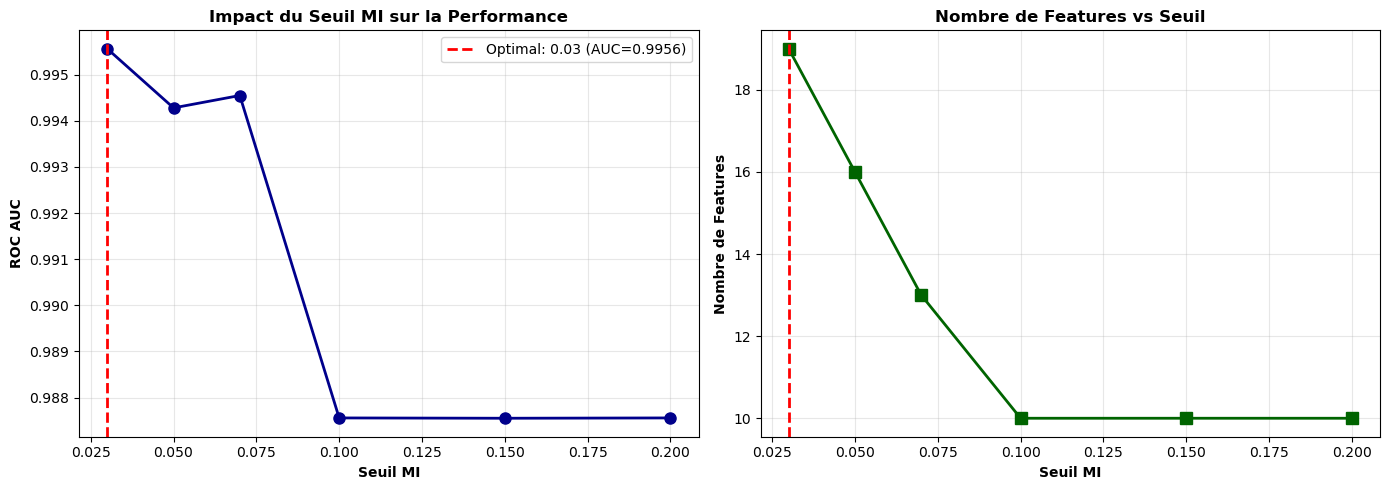


 Features finales retenues : 16

Features retenues :
   1. temps_min_entre_tx_min              (MI: 0.2438)
   2. temps_median_entre_tx_min           (MI: 0.2147)
   3. tx_par_jour                         (MI: 0.1813)
   4. nb_transactions_mois                (MI: 0.1720)
   5. changements_lieu_frequents          (MI: 0.1111)
   6. ratio_montant_max_min               (MI: 0.1063)
   7. total_montant                       (MI: 0.1026)
   8. ratio_max_moyen                     (MI: 0.1008)
   9. montant_std                         (MI: 0.0984)
  10. nb_transactions                     (MI: 0.0958)
  11. velocite_maximale_km_h              (MI: 0.0949)
  12. montant_min                         (MI: 0.0696)
  13. montant_moyen                       (MI: 0.0681)
  14. montants_croissants_consecutifs     (MI: 0.0680)
  15. pct_lieu_principal                  (MI: 0.0349)
  16. nb_tpe_moins_100                    (MI: 0.0338)

📋 VARIABLES SÉLECTIONNÉES PAR MI (avant filtre corrélation) :
---

In [7]:
print("\n4. SÉLECTION DE FEATURES (MUTUAL INFORMATION)")
print("="*80)

# ----------------------------------------------------------------
# CALCUL MI
# ----------------------------------------------------------------
mi_scores = mutual_info_classif(X_all, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_columns_all,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("\n📊 TOP 10 FEATURES (MI):")
print(mi_df.head(10).to_string(index=False))

# ----------------------------------------------------------------
# RECHERCHE DU MEILLEUR SEUIL
# ----------------------------------------------------------------
print("\n🔍 RECHERCHE DU MEILLEUR SEUIL MI")
print("-"*50)

seuils_a_tester = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
MIN_FEATURES = 10
MAX_FEATURES = 20
results_seuils = []

print(f"\n{'Seuil':^10} | {'Nb Features':^12} | {'ROC AUC':^10} | {'Statut':^20}")
print("-"*60)

for seuil in seuils_a_tester:
    feats = mi_df[mi_df['mi_score'] > seuil]['feature'].tolist()
    statut = "OK"

    # Sécurité plancher
    if len(feats) < MIN_FEATURES:
        feats = mi_df.head(MIN_FEATURES)['feature'].tolist()
        statut = f"⚠️ plancher ({MIN_FEATURES})"

    # Sécurité plafond
    if len(feats) > MAX_FEATURES:
        statut = " ignoré (> 20)"
        print(f"{seuil:^10.2f} | {len(feats):^12d} | {'--':^10} | {statut:^20}")
        continue

    X_temp = X_all[feats]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_temp, y, test_size=0.3, random_state=42, stratify=y
    )

    rf_temp = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1
    )
    rf_temp.fit(X_tr, y_tr)
    y_proba_temp = rf_temp.predict_proba(X_te)[:, 1]
    auc_temp = roc_auc_score(y_te, y_proba_temp)

    results_seuils.append({
        'Seuil': seuil,
        'Nb_Features': len(feats),
        'ROC_AUC': auc_temp,
        'Features': feats
    })

    print(f"{seuil:^10.2f} | {len(feats):^12d} | {auc_temp:^10.4f} | {statut:^20}")

# ----------------------------------------------------------------
# MEILLEUR SEUIL
# ----------------------------------------------------------------
results_df = pd.DataFrame(results_seuils)
best_idx  = results_df['ROC_AUC'].idxmax()
best_row  = results_df.loc[best_idx]

best_seuil        = best_row['Seuil']
best_nb_features  = int(best_row['Nb_Features'])
best_auc          = best_row['ROC_AUC']
features_selected = best_row['Features']

print("\n" + "="*60)
print(" MEILLEUR SEUIL TROUVÉ:")
print(f"  Seuil MI    : {best_seuil}")
print(f"  Nb Features : {best_nb_features}")
print(f"  ROC AUC     : {best_auc:.4f}")
print("="*60)

# ----------------------------------------------------------------
# FILTRE CORRÉLATION (après MI)
# ----------------------------------------------------------------
print("\n🔗 FILTRE CORRÉLATION (seuil = 0.85)")
print("-"*60)

CORR_THRESHOLD = 0.85

X_selected_temp = X_all[features_selected]
corr_matrix = X_selected_temp.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    col for col in upper.columns
    if any(upper[col] > CORR_THRESHOLD)
]

#  features_final est la liste utilisée par TOUTES les étapes suivantes
features_final = [f for f in features_selected if f not in to_drop]

print(f"  Features avec MI: {len(features_selected)}")
print(f"  Features supprimées   : {len(to_drop)} → {to_drop if to_drop else 'aucune'}")
print(f"  Features après filtre : {len(features_final)}")

# ----------------------------------------------------------------
# VISUALISATION
# ----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(results_df['Seuil'], results_df['ROC_AUC'],
         marker='o', linewidth=2, markersize=8, color='darkblue')
ax1.axvline(best_seuil, color='red', linestyle='--', linewidth=2,
            label=f'Optimal: {best_seuil} (AUC={best_auc:.4f})')
ax1.set_xlabel('Seuil MI', fontweight='bold')
ax1.set_ylabel('ROC AUC', fontweight='bold')
ax1.set_title('Impact du Seuil MI sur la Performance', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(results_df['Seuil'], results_df['Nb_Features'],
         marker='s', linewidth=2, markersize=8, color='darkgreen')
ax2.axvline(best_seuil, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Seuil MI', fontweight='bold')
ax2.set_ylabel('Nombre de Features', fontweight='bold')
ax2.set_title('Nombre de Features vs Seuil', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mi_seuil_selection.png", dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# X FINAL — utilisé par toutes les étapes suivantes
# ----------------------------------------------------------------
X = X_all[features_final]

print(f"\n Features finales retenues : {len(features_final)}")
print("\nFeatures retenues :")
for i, feat in enumerate(features_final, 1):
    score = mi_df[mi_df['feature'] == feat]['mi_score'].values[0]
    print(f"  {i:2d}. {feat:35s} (MI: {score:.4f})")


# AFFICHAGE : Variables sélectionnées par MI (avant filtre)
# ----------------------------------------------------------------
print("\n📋 VARIABLES SÉLECTIONNÉES PAR MI (avant filtre corrélation) :")
print("-"*60)
for i, feat in enumerate(features_selected, 1):
    score = mi_df[mi_df['feature'] == feat]['mi_score'].values[0]
    print(f"  {i:2d}. {feat:35s} (MI: {score:.4f})")

# ----------------------------------------------------------------
# AFFICHAGE : Variables finales après filtre corrélation
# ----------------------------------------------------------------
print(f"\n VARIABLES FINALES APRÈS FILTRE CORRÉLATION (seuil={CORR_THRESHOLD}) :")
print("-"*60)
for i, feat in enumerate(features_final, 1):
    score = mi_df[mi_df['feature'] == feat]['mi_score'].values[0]
    print(f"  {i:2d}. {feat:35s} (MI: {score:.4f})")

print(f"\n  ➡ {len(features_selected)} → {len(features_final)} variables "
      f"({len(to_drop)} supprimées : {to_drop if to_drop else 'aucune'})")

## ✂ 5. TRAIN/TEST SPLIT

In [8]:
print("\n5. TRAIN/TEST SPLIT")
print("-"*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✓ Train: {len(X_train)} comptes")
print(f"✓ Test: {len(X_test)} comptes")
print(f"\n Distribution Train:")
print(y_train.value_counts())


5. TRAIN/TEST SPLIT
--------------------------------------------------------------------------------
✓ Train: 1986 comptes
✓ Test: 852 comptes

 Distribution Train:
anomalie
0.0    1762
1.0     224
Name: count, dtype: int64


## 6. Standardisation DES DONNÉES

In [9]:
print("\n6. Standardisation (StandardScaler)")
print("="*80)

# StandardScaler (pour tous les modèles)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrame pour garder les noms
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_final)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_final)

print("✓ Normalisation StandardScaler appliquée")
print(f"  - Moyenne Train: {X_train_scaled.mean().mean():.4f}")
print(f"  - Std Train: {X_train_scaled.std().mean():.4f}")


6. NORMALISATION (StandardScaler)
✓ Normalisation StandardScaler appliquée
  - Moyenne Train: -0.0000
  - Std Train: 1.0003


## 7.APPLICATION SMOTE

In [10]:
print("\n7. APPLICATION SMOTE")
print("-"*80)

smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("📊 AVANT SMOTE:")
print(y_train.value_counts())
print("\n📊 APRÈS SMOTE:")
print(pd.Series(y_train_smote).value_counts())


7. APPLICATION SMOTE
--------------------------------------------------------------------------------
📊 AVANT SMOTE:
anomalie
0.0    1762
1.0     224
Name: count, dtype: int64

📊 APRÈS SMOTE:
anomalie
0.0    1762
1.0     528
Name: count, dtype: int64


##  8. DÉFINITION DES MODÈLES ET PARAMÈTRES

In [11]:
print("\n8. CONFIGURATION DES MODÈLES")
print("="*80)

# Dictionnaire des modèles avec leurs grilles de paramètres
models_and_parameters = {
    
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs", "saga"]
        }
    },
    
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        }
    },
    
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5]
        }
    },
    
    "XGBoost": {
        "model": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6],
            "learning_rate": [0.01, 0.1],
            "subsample": [0.8, 1.0]
        }
    },
    
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {}
    }
}

print(f"✓ {len(models_and_parameters)} modèles configurés")
for name in models_and_parameters.keys():
    print(f"  - {name}")


8. CONFIGURATION DES MODÈLES
✓ 7 modèles configurés
  - Logistic Regression
  - Random Forest
  - Decision Tree
  - XGBoost
  - KNN
  - SVM
  - Naive Bayes


##  9. ENTRAÎNEMENT ET ÉVALUATION DE TOUS LES MODÈLES

In [12]:
print("\n9. ENTRAÎNEMENT ET ÉVALUATION")
print("="*80)

# Stocker résultats
results = {}
best_models = {}

# Scorer pour GridSearch
scorer = make_scorer(roc_auc_score, needs_proba=True)

for model_name, config in models_and_parameters.items():
    print(f"\n{'='*80}")
    print(f" ENTRAÎNEMENT: {model_name}")
    print(f"{'='*80}")
    
    try:
        # GridSearchCV
        if config["params"]:
            print(f" GridSearch en cours...")
            grid = GridSearchCV(
                config["model"],
                config["params"],
                cv=5,
                scoring=scorer,
                n_jobs=-1,
                verbose=0
            )
            grid.fit(X_train_smote, y_train_smote)
            best_model = grid.best_estimator_
            
            print(f"\n Meilleurs paramètres:")
            for param, value in grid.best_params_.items():
                print(f"  - {param}: {value}")
        else:
            # Modèle sans hyperparamètres (Naive Bayes)
            best_model = config["model"]
            best_model.fit(X_train_smote, y_train_smote)
        
        # Sauvegarder modèle
        best_models[model_name] = best_model
        
        # Prédictions
        y_pred = best_model.predict(X_test_scaled)
        y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
        
        # Métriques
        roc_auc = roc_auc_score(y_test, y_proba)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        # Sauvegarder résultats
        results[model_name] = {
            "ROC_AUC": roc_auc,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Confusion_Matrix": cm,
            "y_proba": y_proba
        }
        
        # Affichage
        print(f"\n RÉSULTATS {model_name}:")
        print(f"  ROC AUC:   {roc_auc:.4f}")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"\n Confusion Matrix:")
        print(cm)
        
    except Exception as e:
        print(f" ERREUR avec {model_name}: {str(e)}")
        continue

print(f"\n{'='*80}")
print(" TOUS LES MODÈLES ENTRAÎNÉS")
print(f"{'='*80}")


9. ENTRAÎNEMENT ET ÉVALUATION

 ENTRAÎNEMENT: Logistic Regression
 GridSearch en cours...

 Meilleurs paramètres:
  - C: 10
  - penalty: l2
  - solver: lbfgs

 RÉSULTATS Logistic Regression:
  ROC AUC:   0.9853
  Accuracy:  0.9754
  Precision: 0.8788
  Recall:    0.9062
  F1-Score:  0.8923

 Confusion Matrix:
[[744  12]
 [  9  87]]

 ENTRAÎNEMENT: Random Forest
 GridSearch en cours...

 Meilleurs paramètres:
  - max_depth: None
  - min_samples_leaf: 1
  - min_samples_split: 5
  - n_estimators: 100

 RÉSULTATS Random Forest:
  ROC AUC:   0.9964
  Accuracy:  0.9859
  Precision: 0.9667
  Recall:    0.9062
  F1-Score:  0.9355

 Confusion Matrix:
[[753   3]
 [  9  87]]

 ENTRAÎNEMENT: Decision Tree
 GridSearch en cours...

 Meilleurs paramètres:
  - max_depth: 5
  - min_samples_leaf: 2
  - min_samples_split: 5

 RÉSULTATS Decision Tree:
  ROC AUC:   0.9859
  Accuracy:  0.9777
  Precision: 0.9231
  Recall:    0.8750
  F1-Score:  0.8984

 Confusion Matrix:
[[749   7]
 [ 12  84]]

 ENTRAÎNEME

## 10. TABLEAU COMPARATIF DES PERFORMANCES

In [13]:
print("\n10. TABLEAU COMPARATIF")
print("="*80)

# Créer DataFrame comparatif
comparison_df = pd.DataFrame({
    "Modèle": list(results.keys()),
    "ROC AUC": [results[m]["ROC_AUC"] for m in results.keys()],
    "Accuracy": [results[m]["Accuracy"] for m in results.keys()],
    "Precision": [results[m]["Precision"] for m in results.keys()],
    "Recall": [results[m]["Recall"] for m in results.keys()],
    "F1-Score": [results[m]["F1_Score"] for m in results.keys()]
}).sort_values("ROC AUC", ascending=False)

print("\n TABLEAU DE PERFORMANCES (Trié par ROC AUC):")
print(comparison_df.to_string(index=False))


10. TABLEAU COMPARATIF

 TABLEAU DE PERFORMANCES (Trié par ROC AUC):
             Modèle  ROC AUC  Accuracy  Precision   Recall  F1-Score
      Random Forest 0.996376  0.985915   0.966667 0.906250  0.935484
            XGBoost 0.995219  0.984742   0.946237 0.916667  0.931217
                SVM 0.988481  0.976526   0.887755 0.906250  0.896907
      Decision Tree 0.985891  0.977700   0.923077 0.875000  0.898396
Logistic Regression 0.985326  0.975352   0.878788 0.906250  0.892308
                KNN 0.979422  0.970657   0.898876 0.833333  0.864865
        Naive Bayes 0.952512  0.942488   0.732673 0.770833  0.751269


## 🏆 11. SÉLECTION DU MEILLEUR MODÈLE

In [14]:
print("\n11. SÉLECTION DU MEILLEUR MODÈLE")
print("="*80)

# Trouver meilleur modèle selon ROC AUC
best_model_name = comparison_df.iloc[0]["Modèle"]
best_model = best_models[best_model_name]
best_results = results[best_model_name]

print(f"\n MEILLEUR MODÈLE: {best_model_name}")
print(f"{'='*80}")
print(f"\n PERFORMANCES:")
print(f"  ROC AUC:   {best_results['ROC_AUC']:.4f}")
print(f"  Accuracy:  {best_results['Accuracy']:.4f}")
print(f"  Precision: {best_results['Precision']:.4f}")
print(f"  Recall:    {best_results['Recall']:.4f}")
print(f"  F1-Score:  {best_results['F1_Score']:.4f}")

print(f"\n Confusion Matrix:")
print(best_results['Confusion_Matrix'])

# Classification Report détaillé
y_pred_best = best_model.predict(X_test_scaled)
print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Anomalie']))


11. SÉLECTION DU MEILLEUR MODÈLE

 MEILLEUR MODÈLE: Random Forest

 PERFORMANCES:
  ROC AUC:   0.9964
  Accuracy:  0.9859
  Precision: 0.9667
  Recall:    0.9062
  F1-Score:  0.9355

 Confusion Matrix:
[[753   3]
 [  9  87]]

 Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       756
    Anomalie       0.97      0.91      0.94        96

    accuracy                           0.99       852
   macro avg       0.98      0.95      0.96       852
weighted avg       0.99      0.99      0.99       852



##  12. VISUALISATIONS COMPARATIVES


12. VISUALISATIONS


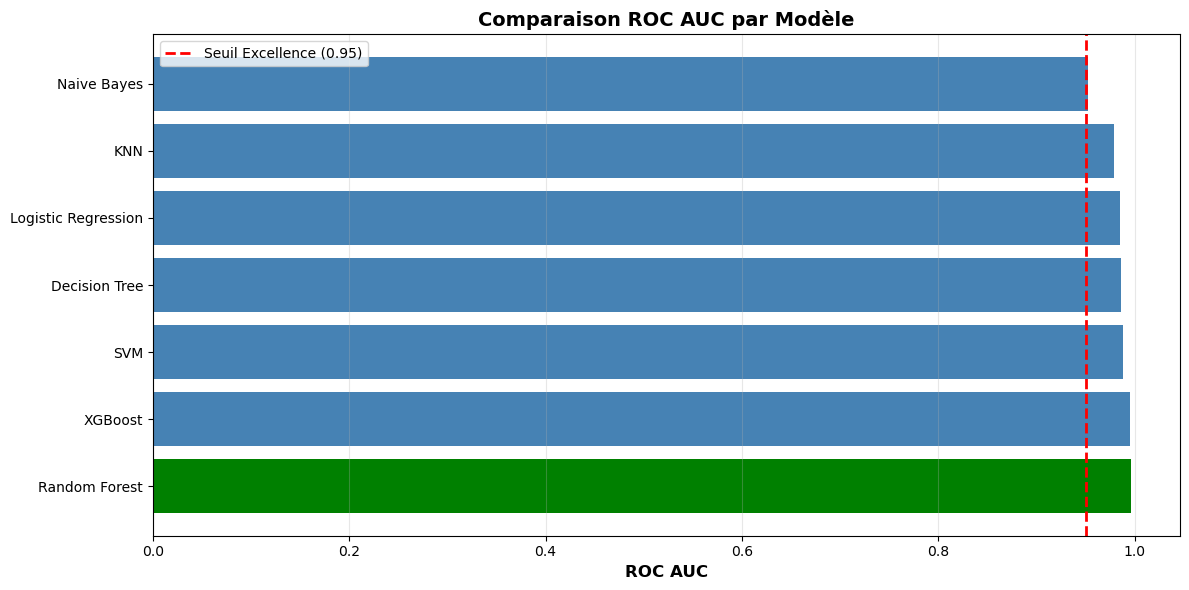

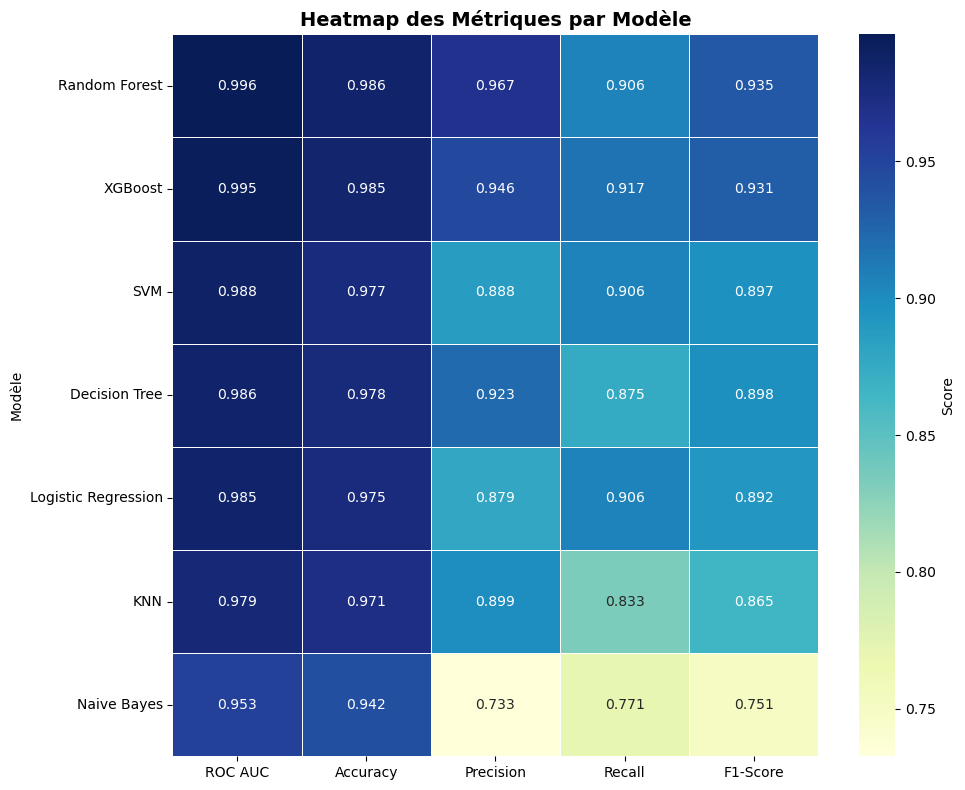

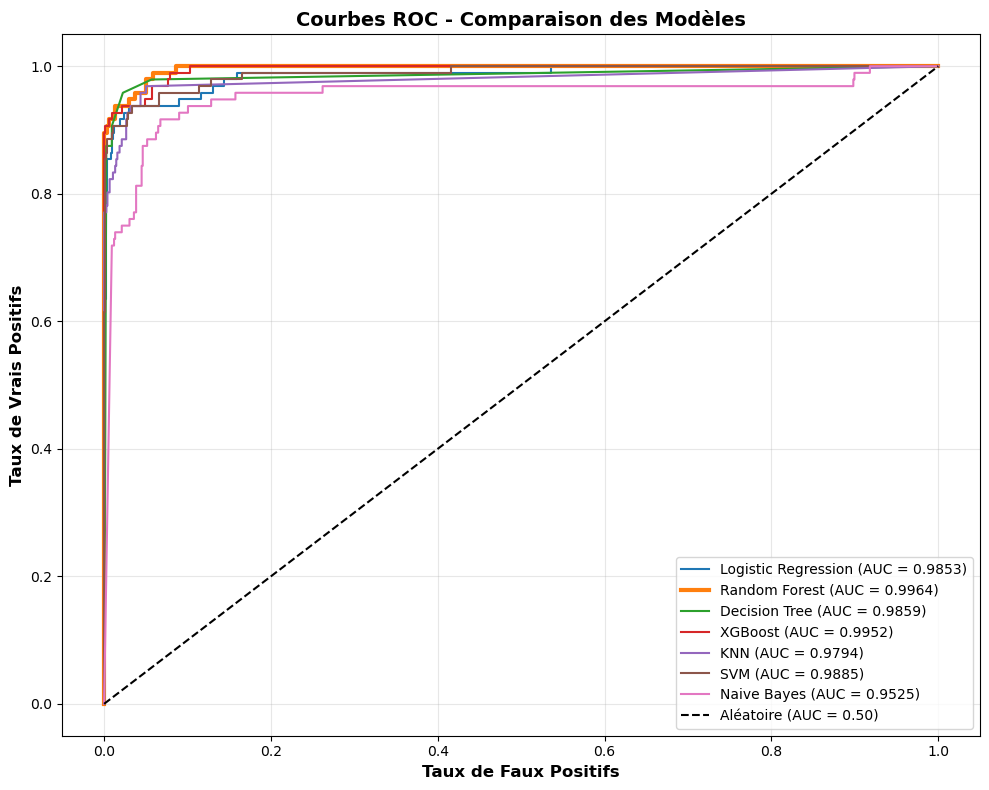

✓ Visualisations affichées


In [15]:
print("\n12. VISUALISATIONS")
print("="*80)

# 1. Barplot des ROC AUC
plt.figure(figsize=(12, 6))
colors = ['green' if m == best_model_name else 'steelblue' for m in comparison_df['Modèle']]
plt.barh(comparison_df['Modèle'], comparison_df['ROC AUC'], color=colors)
plt.xlabel('ROC AUC', fontweight='bold', fontsize=12)
plt.title('Comparaison ROC AUC par Modèle', fontweight='bold', fontsize=14)
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Seuil Excellence (0.95)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Heatmap des métriques
metrics_df = comparison_df.set_index('Modèle')
plt.figure(figsize=(10, 8))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlGnBu', 
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.title('Heatmap des Métriques par Modèle', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Courbes ROC comparatives
plt.figure(figsize=(10, 8))
for model_name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[model_name]['y_proba'])
    auc = results[model_name]['ROC_AUC']
    linewidth = 3 if model_name == best_model_name else 1.5
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=linewidth)

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs', fontweight='bold', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontweight='bold', fontsize=12)
plt.title('Courbes ROC - Comparaison des Modèles', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Visualisations affichées")


12. ANALYSE SHAP PAR MODÈLE

 SHAP - Logistic Regression


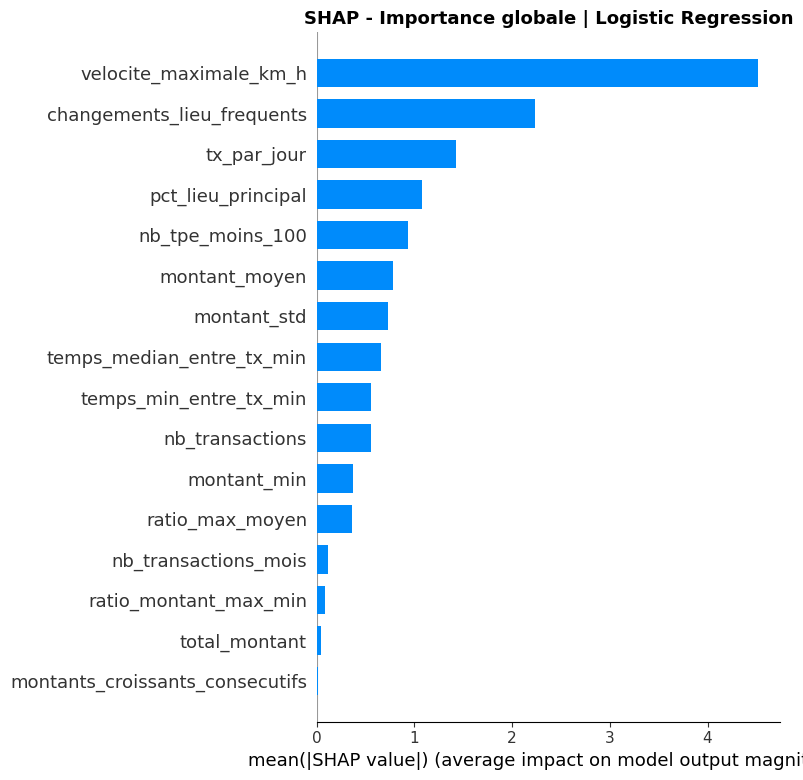

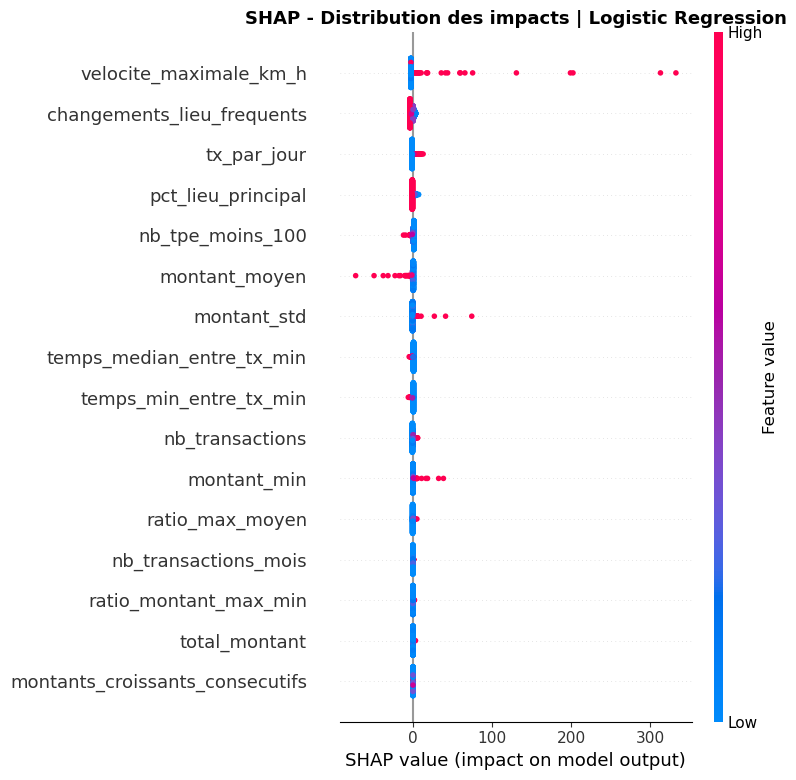


   Waterfall : transaction suspecte index 33


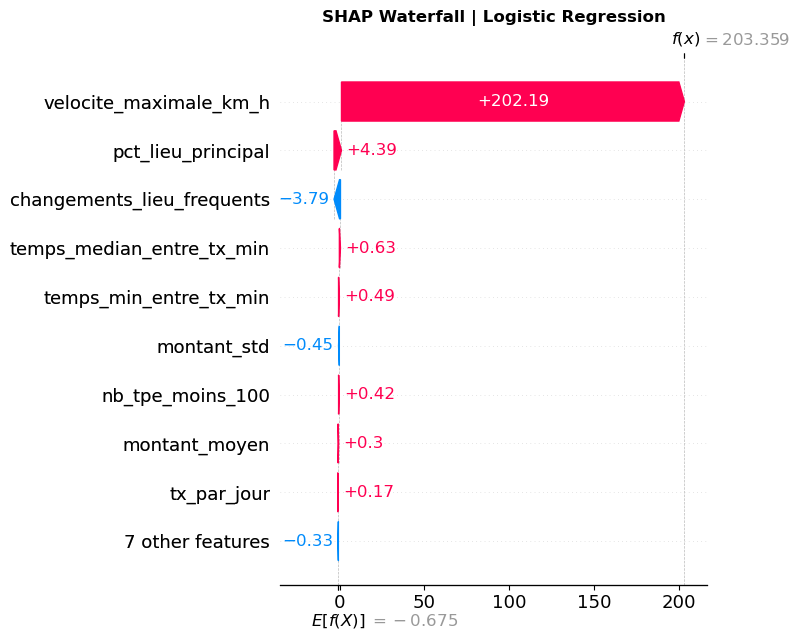


   Top 5 features (Logistic Regression):
                   Feature  Mean |SHAP|
    velocite_maximale_km_h     4.515936
changements_lieu_frequents     2.238376
               tx_par_jour     1.426925
        pct_lieu_principal     1.082379
          nb_tpe_moins_100     0.930674

 SHAP - Random Forest


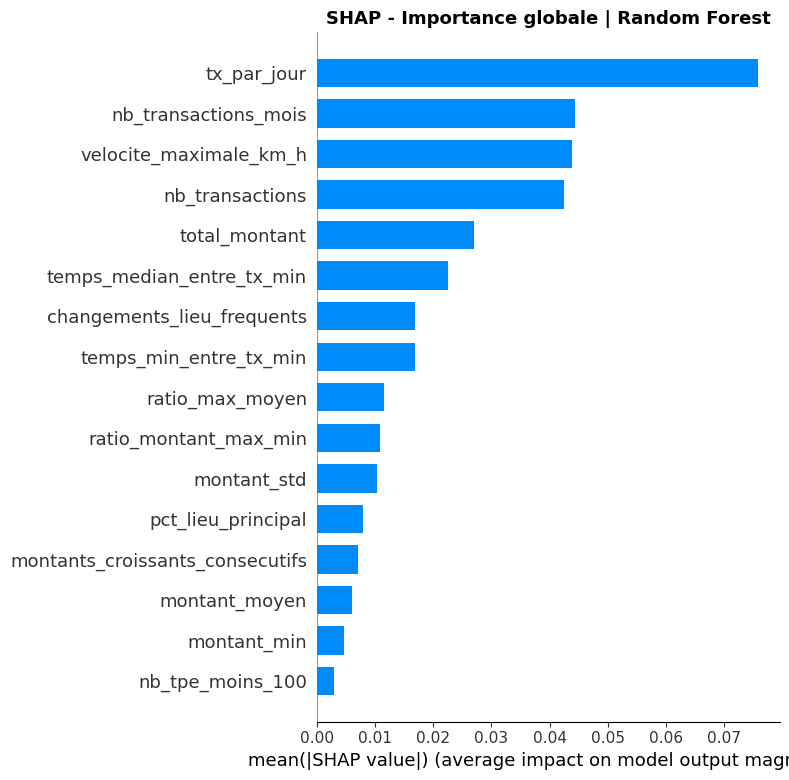

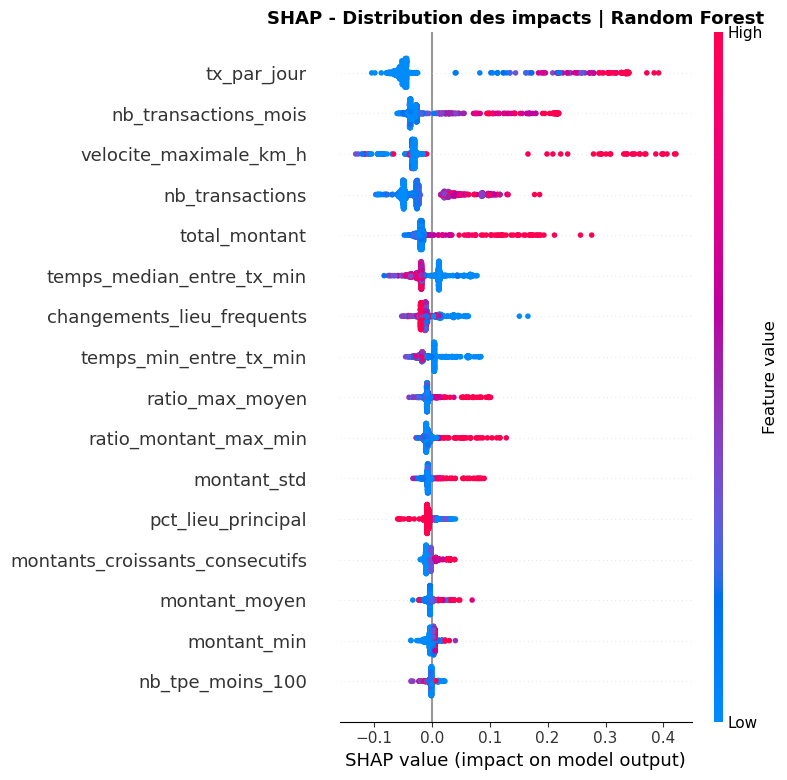


   Waterfall : transaction suspecte index 33


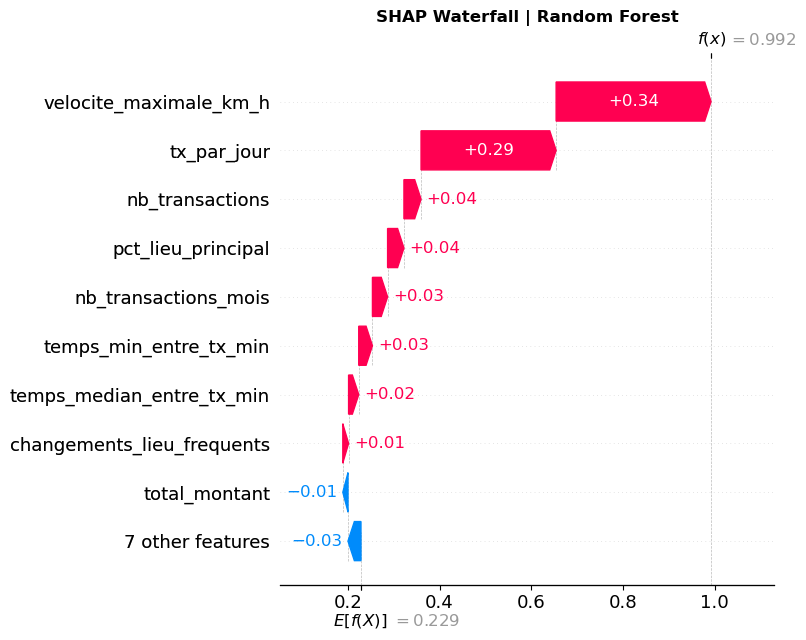


   Top 5 features (Random Forest):
               Feature  Mean |SHAP|
           tx_par_jour     0.075795
  nb_transactions_mois     0.044344
velocite_maximale_km_h     0.043932
       nb_transactions     0.042475
         total_montant     0.027008

 SHAP - Decision Tree


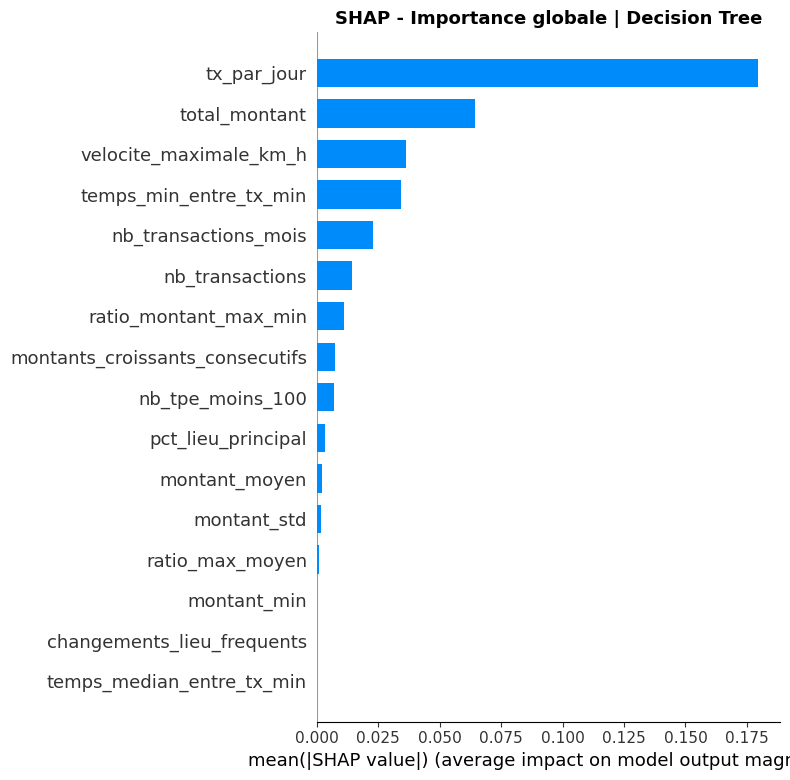

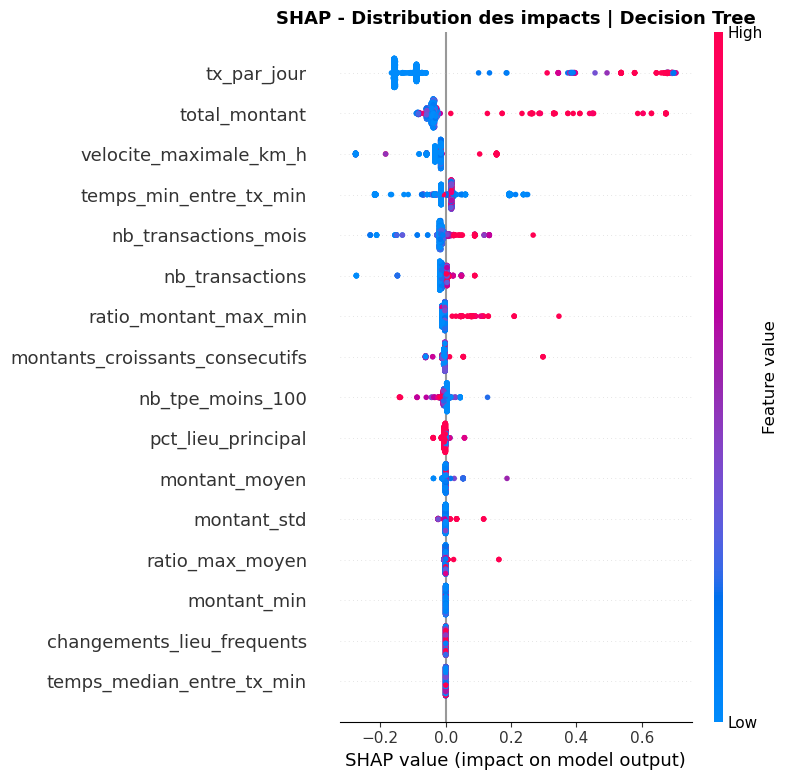


   Waterfall : transaction suspecte index 33


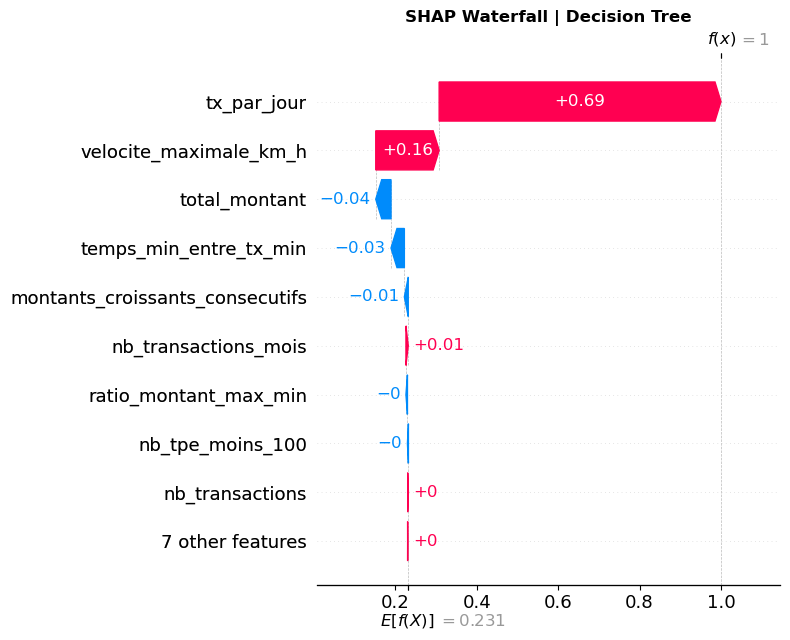


   Top 5 features (Decision Tree):
               Feature  Mean |SHAP|
           tx_par_jour     0.179482
         total_montant     0.064579
velocite_maximale_km_h     0.036265
temps_min_entre_tx_min     0.034136
  nb_transactions_mois     0.022765

 SHAP - XGBoost


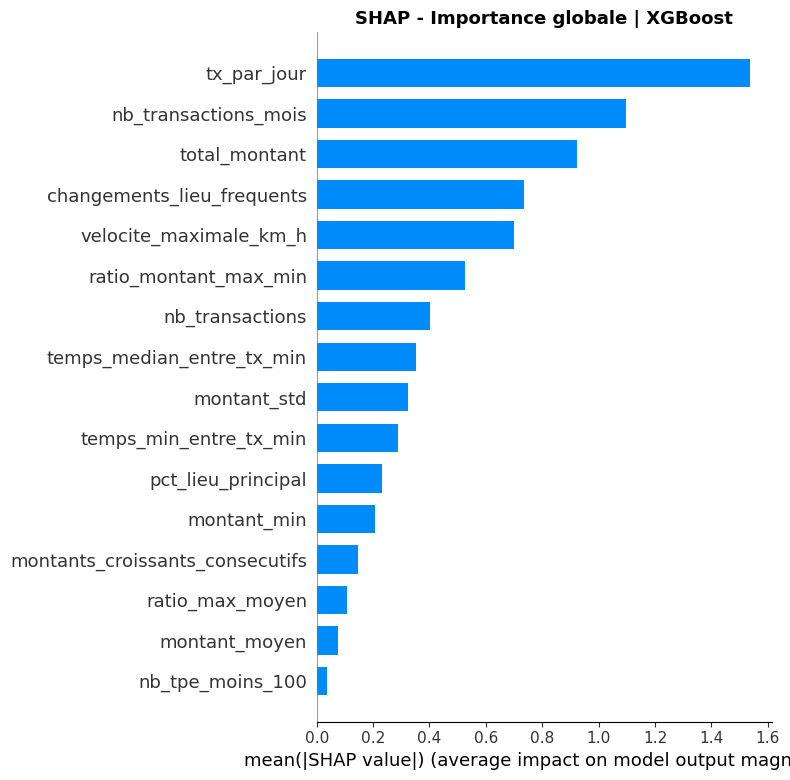

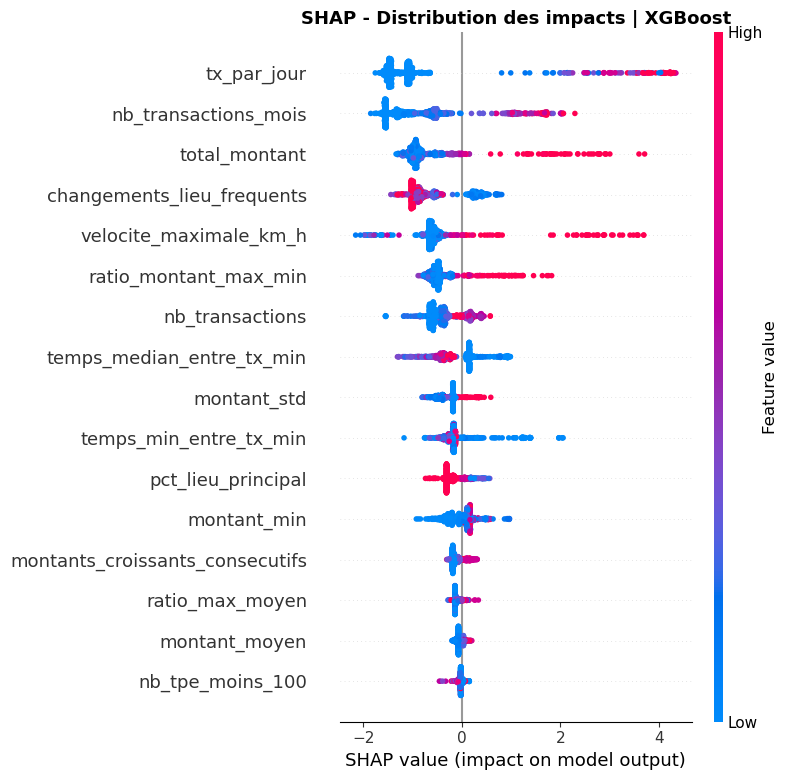


   Waterfall : transaction suspecte index 33


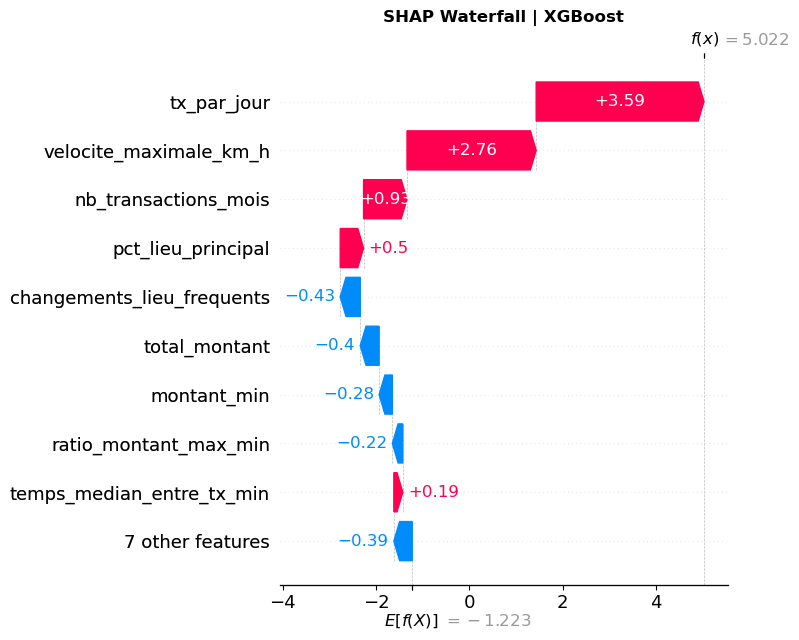


   Top 5 features (XGBoost):
                   Feature  Mean |SHAP|
               tx_par_jour     1.537771
      nb_transactions_mois     1.096068
             total_montant     0.924874
changements_lieu_frequents     0.735082
    velocite_maximale_km_h     0.699366

 SHAP - KNN
   KernelExplainer sur 100 échantillons...


  0%|          | 0/100 [00:00<?, ?it/s]

   ERREUR SHAP KNN: only length-1 arrays can be converted to Python scalars

 SHAP - SVM
   KernelExplainer sur 100 échantillons...


  0%|          | 0/100 [00:00<?, ?it/s]

   ERREUR SHAP SVM: only length-1 arrays can be converted to Python scalars

 SHAP - Naive Bayes
   KernelExplainer sur 100 échantillons...


  0%|          | 0/100 [00:00<?, ?it/s]

   ERREUR SHAP Naive Bayes: only length-1 arrays can be converted to Python scalars

✅ ANALYSE SHAP TERMINÉE


In [16]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n12. ANALYSE SHAP PAR MODÈLE")
print("="*80)

X_test_df_full  = pd.DataFrame(X_test_scaled,  columns=features_final)
X_train_df_full = pd.DataFrame(X_train_smote,  columns=features_final)

# ============================================================
# Fonction d'affichage — identique pour tous les modèles
# ============================================================
def plot_shap(model_name, shap_vals, X_df, expected_val, y_test_aligned, best_model):
    """
    shap_vals  : np.ndarray 2D (n_samples, n_features) — valeurs SHAP classe 1
    expected_val : float — valeur de base (E[f(X)])
    """

    # ── 1. Bar plot (importance globale) ─────────────────────────────────────
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        shap_vals,
        X_df,
        feature_names=features_final,
        plot_type="bar",
        show=False
    )
    plt.title(f"SHAP - Importance globale | {model_name}", fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 2. Beeswarm (distribution des impacts) ───────────────────────────────
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_vals,
        X_df,
        feature_names=features_final,
        plot_type="dot",   # ← forcer "dot" = beeswarm identique pour tous
        show=False
    )
    plt.title(f"SHAP - Distribution des impacts | {model_name}", fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 3. Waterfall (premier vrai positif) ──────────────────────────────────
    y_pred_model = best_model.predict(X_df)
    tp_indices   = np.where((np.array(y_test_aligned) == 1) & (y_pred_model == 1))[0]

    if len(tp_indices) > 0:
        idx = tp_indices[0]
        print(f"\n   Waterfall : transaction suspecte index {idx}")

        sv = shap_vals[idx]          # vecteur 1D (n_features,)
        ev = float(expected_val)

        plt.figure()
        shap.plots._waterfall.waterfall_legacy(
            ev, sv,
            feature_names=features_final,
            show=False
        )
        plt.title(f"SHAP Waterfall | {model_name}", fontweight='bold', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("   Aucun vrai positif trouvé pour le waterfall")

    # ── 4. Top 5 features ────────────────────────────────────────────────────
    mean_shap = np.abs(shap_vals).mean(axis=0)
    top5 = (pd.DataFrame({'Feature': features_final, 'Mean |SHAP|': mean_shap})
              .sort_values('Mean |SHAP|', ascending=False)
              .head(5))
    print(f"\n   Top 5 features ({model_name}):")
    print(top5.to_string(index=False))


# ============================================================
# Boucle principale — même format pour tous les modèles
# ============================================================
for model_name, best_model in best_models.items():
    print(f"\n{'='*60}")
    print(f" SHAP - {model_name}")
    print(f"{'='*60}")

    try:
        # ── Choix de l'explainer selon le type de modèle ─────────────────────
        if model_name in ["Random Forest", "Decision Tree", "XGBoost"]:
            explainer = shap.TreeExplainer(best_model)
            raw_vals  = explainer.shap_values(X_test_df_full)
            raw_ev    = explainer.expected_value

            # TreeExplainer → liste [classe0, classe1] ou array 3D (n, f, 2)
            if isinstance(raw_vals, list):
                # Random Forest / Decision Tree : liste de deux arrays
                shap_vals  = np.array(raw_vals[1])   # classe 1
                expected_v = float(raw_ev[1])
            elif isinstance(raw_vals, np.ndarray) and raw_vals.ndim == 3:
                # Parfois shape (n_samples, n_features, n_classes)
                shap_vals  = raw_vals[:, :, 1]
                expected_v = float(raw_ev[1]) if hasattr(raw_ev, '__len__') else float(raw_ev)
            else:
                # XGBoost binary → array 2D directement
                shap_vals  = np.array(raw_vals)
                expected_v = float(raw_ev[1]) if hasattr(raw_ev, '__len__') else float(raw_ev)

            plot_shap(model_name, shap_vals, X_test_df_full,
                      expected_v, np.array(y_test), best_model)

        elif model_name == "Logistic Regression":
            explainer = shap.LinearExplainer(best_model, X_train_df_full)
            raw_vals  = explainer.shap_values(X_test_df_full)
            raw_ev    = explainer.expected_value

            shap_vals  = np.array(raw_vals[1]) if isinstance(raw_vals, list) else np.array(raw_vals)
            expected_v = float(raw_ev[1])      if isinstance(raw_ev,  list) else float(raw_ev)

            plot_shap(model_name, shap_vals, X_test_df_full,
                      expected_v, np.array(y_test), best_model)

        else:
            # KNN, SVM, Naive Bayes → KernelExplainer (lent, sous-ensemble)
            print(f"   KernelExplainer sur 100 échantillons...")
            background = shap.sample(X_train_df_full, 50)
            explainer  = shap.KernelExplainer(best_model.predict_proba, background)
            X_sub      = X_test_df_full.iloc[:100]
            raw_vals   = explainer.shap_values(X_sub)
            raw_ev     = explainer.expected_value

            shap_vals  = np.array(raw_vals[1]) if isinstance(raw_vals, list) else np.array(raw_vals)
            expected_v = float(raw_ev[1])      if isinstance(raw_ev,  list) else float(raw_ev)

            plot_shap(model_name, shap_vals, X_sub,
                      expected_v, np.array(y_test)[:100], best_model)

    except Exception as e:
        print(f"   ERREUR SHAP {model_name}: {e}")

print("\n✅ ANALYSE SHAP TERMINÉE")

In [18]:
"""
=============================================================================
CELLULE À AJOUTER À LA FIN DU NOTEBOOK
Comparaison_Modeles_Supervises_Complet.ipynb
=============================================================================
Placez cette cellule APRÈS la section "11. SÉLECTION DU MEILLEUR MODÈLE"
(après que best_model, scaler et features_final sont définis)
=============================================================================
"""

import os, joblib

# ── Dossier de sauvegarde ─────────────────────────────────────────────────
save_dir = r"C:\Users\Pc\Desktop\crisp-dm\Project_PFE\model"   # ← adaptez si besoin
os.makedirs(save_dir, exist_ok=True)

# ── Sauvegarde du modèle Random Forest ───────────────────────────────────
# best_model est le modèle sélectionné (Random Forest selon vos résultats)
xgb_path = os.path.join(save_dir, "xgboost.pkl")
joblib.dump(best_model, xgb_path)   # best_model = XGBoost ici
print(f"✓ Modèle sauvegardé  : {xgb_path}")

# ── Sauvegarde du StandardScaler ─────────────────────────────────────────
# scaler est l'objet StandardScaler ajusté sur X_train
scaler_path = os.path.join(save_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler sauvegardé  : {scaler_path}")

# ── Sauvegarde de la liste des features finales ───────────────────────────
# features_final est la liste issue de la sélection par Mutual Information
features_path = os.path.join(save_dir, "features.pkl")
joblib.dump(features_final, features_path)
print(f"✓ Features sauvegardées : {features_path}")
print(f"  → {len(features_final)} features : {features_final}")

# ── Vérification rapide du rechargement ──────────────────────────────────
print("\n Vérification du rechargement...")
model_check = joblib.load(xgb_path)
scaler_check  = joblib.load(scaler_path)
feats_check   = joblib.load(features_path)

X_verif = X_test_scaled[feats_check].iloc[:3]
preds   = model_check.predict(X_verif)
probas  = model_check.predict_proba(X_verif)[:, 1]

print(f"  Prédictions test : {preds}")
print(f"  Probabilités     : {[round(p,3) for p in probas]}")
print("\n Sauvegarde et rechargement OK — modèle prêt pour l'API Flask")

✓ Modèle sauvegardé  : C:\Users\Pc\Desktop\crisp-dm\Project_PFE\model\xgboost.pkl
✓ Scaler sauvegardé  : C:\Users\Pc\Desktop\crisp-dm\Project_PFE\model\scaler.pkl
✓ Features sauvegardées : C:\Users\Pc\Desktop\crisp-dm\Project_PFE\model\features.pkl
  → 16 features : ['temps_min_entre_tx_min', 'temps_median_entre_tx_min', 'tx_par_jour', 'nb_transactions_mois', 'changements_lieu_frequents', 'ratio_montant_max_min', 'total_montant', 'ratio_max_moyen', 'montant_std', 'nb_transactions', 'velocite_maximale_km_h', 'montant_min', 'montant_moyen', 'montants_croissants_consecutifs', 'pct_lieu_principal', 'nb_tpe_moins_100']

 Vérification du rechargement...
  Prédictions test : [0. 0. 0.]
  Probabilités     : [0.0, 0.0, 0.0]

 Sauvegarde et rechargement OK — modèle prêt pour l'API Flask
